In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from metrics import treatment_effect
from auton_survival import reporting
from matplotlib.pyplot import figure

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load PEACE dataset
from datasets_retrospective import load_peace_dataset
outcomes, features, intervention, cat_feats, num_feats = load_peace_dataset(location='datasets/PEACE/Data/', outcome='PRIMARY')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:965: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1147: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1148: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1149: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

(8290, 7)
(8290, 39)
(8290, 7)
(8290, 39)


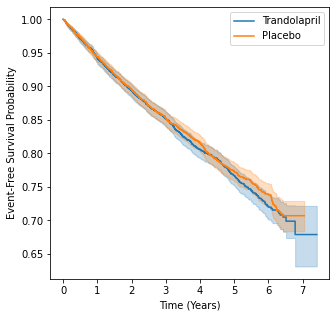

In [3]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_0 = reporting.plot_kaplanmeier(outcomes, intervention)
h, l = ax_0.get_legend_handles_labels()
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()
pass

In [5]:
print(features.shape)
features.head()

(8290, 45)


,Baseline_Use_Diet_Control,Baseline_Canadian_Cardiovascular_Society_Classification,Baseline_Use_Other_Diuretics,Baseline_History_Intermittent_Claudication,Baseline_Weight_KG,Baseline_Skin_Rash,Baseline_History_Percutaneous_Coronary_Intervention,Baseline_History_Transient_Ischemic_Attack,Baseline_History_Coronary_Artery_Bypass_Graft,Sex,...,Baseline_Use_Oral_Agents,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Total_Cholesterol,Baseline_Potassium,Baseline_History_Insulin,Baseline_Left_Ventricular_Function_Qualitative_Abnormal,Baseline_Estimated_Glomerular_Filtration_Rate,Baseline_Use_Anti_Arrhythmic,Baseline_History_Dizziness,Baseline_Lipid_Lowering_Therapy
NEW_ID,,,,,,,,,,,,,,,,,,,,,
10007.0,NaN,I,No,No,72.0,No,No,No,No,Male,...,Yes,150.0,361.0,4.8,NaN,Yes,66.0,No,No,No
10026.0,NaN,I,No,No,107.0,No,No,No,Yes,Male,...,NaN,142.0,157.0,4.3,NaN,Yes,86.0,No,No,Yes
10027.0,NaN,No symptoms of angina,No,No,84.0,No,Yes,No,No,Male,...,NaN,115.0,209.0,4.8,NaN,Yes,72.0,No,No,Yes
10040.0,NaN,I,No,Yes,85.0,No,No,No,No,Male,...,NaN,140.0,158.0,4.4,NaN,NaN,65.0,No,No,Yes
10042.0,NaN,No symptoms of angina,No,No,83.0,No,Yes,No,No,Male,...,NaN,126.0,166.0,4.3,NaN,No,105.0,No,No,No


In [4]:
print(outcomes.shape)
outcomes.head()

(8290, 2)


,time,event
NEW_ID,,
10007.0,4.492813,False
10026.0,2.516085,False
10027.0,4.465435,False
10040.0,6.340862,True
10042.0,2.510609,True


In [7]:
print(intervention.shape)
intervention.head()

(8290,)


NEW_ID
10007.0    Trandolapril
10026.0         Placebo
10027.0         Placebo
10040.0         Placebo
10042.0    Trandolapril
Name: TX, dtype: object

In [8]:
# Specify categorical and numeric features used for training the model
cat_feats=['Sex', 'Baseline_Smoke_status']
num_feats=['Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [9]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [10]:
# Let's see the data after preprocessing
features_prep.head()

,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Seated_Diastolic_Blood_Pressure,Sex_Male,Baseline_Smoke_status_Ever,Baseline_Smoke_status_Never
NEW_ID,,,,,
10007.0,1.364896,0.570418,1,0,1
10026.0,0.880148,1.712760,1,1,0
10027.0,-0.755875,-0.468074,1,1,0
10040.0,0.758962,0.778117,1,0,1
10042.0,-0.089347,0.362720,1,0,1


In [11]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.
random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [12]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='Trandolapril', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:36<00:00,  2.75it/s]


In [13]:
zeta_probs = model.predict_latent_phi(features_prep)
zeta = np.argmax(zeta_probs, axis=1)

Confidence Interval for Zeta 0 is [1.03666922 1.41555366]

Confidence Interval for Zeta 1 is [0.77591736 0.98733914]

In [14]:
hr_zeta0 = treatment_effect('hazard_ratio', outcomes[zeta == 0], intervention[zeta == 0] == 'Trandolapril', n_bootstrap=100)
CI_zeta0 = np.quantile(hr_zeta0, [0.025, 0.975])
CI_zeta0

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...


array([1.03666922, 1.41555366])

In [15]:
hr_zeta1 = treatment_effect('hazard_ratio', outcomes[zeta == 1], intervention[zeta == 1] == 'Trandolapril', n_bootstrap=100)
CI_zeta1 = np.quantile(hr_zeta1, [0.025, 0.975])
CI_zeta1

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...


array([0.77591736, 0.98733914])

In [16]:
print((zeta == 0).sum())
print((zeta == 1).sum())

2640
5650


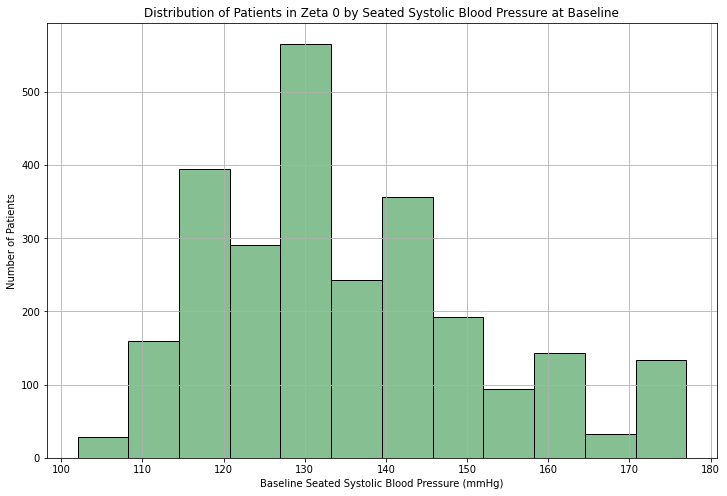

In [17]:
# Plot distribution of patients by Seated Systolic Blood Pressure at Baseline
plt.figure(figsize=(12,8))
n, bins, patches = plt.hist(features[zeta == 0].Baseline_Seated_Systolic_Blood_Pressure, 12, facecolor='#86bf91', edgecolor='black')
plt.xlabel('Baseline Seated Systolic Blood Pressure (mmHg)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patients in Zeta 0 by Seated Systolic Blood Pressure at Baseline')
plt.grid(True)
plt.show()

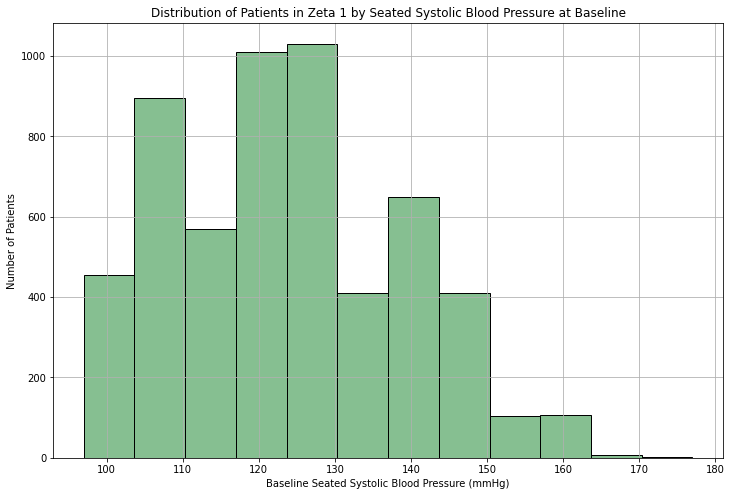

In [18]:
# Plot distribution of patients by Seated Systolic Blood Pressure at Baseline
plt.figure(figsize=(12,8))
n, bins, patches = plt.hist(features[zeta == 1].Baseline_Seated_Systolic_Blood_Pressure, 12, facecolor='#86bf91', edgecolor='black')
plt.xlabel('Baseline Seated Systolic Blood Pressure (mmHg)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patients in Zeta 1 by Seated Systolic Blood Pressure at Baseline')
plt.grid(True)
plt.show()

In [19]:
(features[zeta == 1].Baseline_Seated_Systolic_Blood_Pressure).describe()

count    5649.000000
mean      123.921579
std        15.249868
min        97.000000
25%       112.000000
50%       122.000000
75%       135.000000
max       177.000000
Name: Baseline_Seated_Systolic_Blood_Pressure, dtype: float64

In [20]:
(features[zeta == 0].Baseline_Seated_Systolic_Blood_Pressure).describe()

count    2635.000000
mean      135.091461
std        16.535723
min       102.000000
25%       122.000000
50%       130.000000
75%       142.000000
max       177.000000
Name: Baseline_Seated_Systolic_Blood_Pressure, dtype: float64

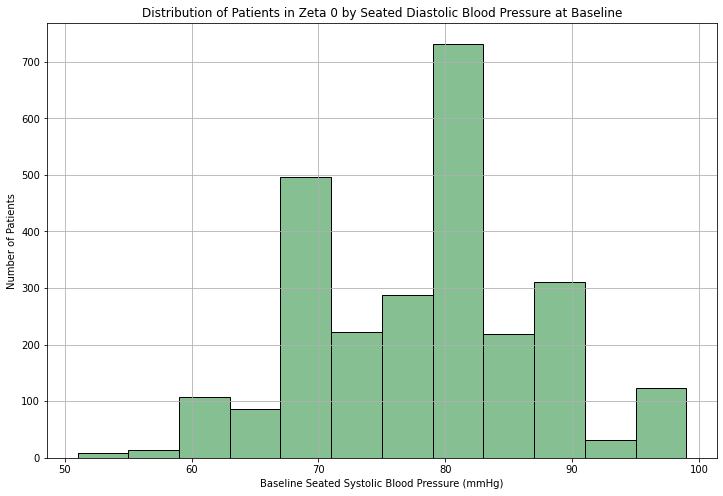

In [21]:
# Plot distribution of patients by Seated Diastolic Blood Pressure at Baseline
plt.figure(figsize=(12,8))
n, bins, patches = plt.hist(features[zeta == 0].Baseline_Seated_Diastolic_Blood_Pressure, 12, facecolor='#86bf91', edgecolor='black')
plt.xlabel('Baseline Seated Systolic Blood Pressure (mmHg)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patients in Zeta 0 by Seated Diastolic Blood Pressure at Baseline')
plt.grid(True)
plt.show()

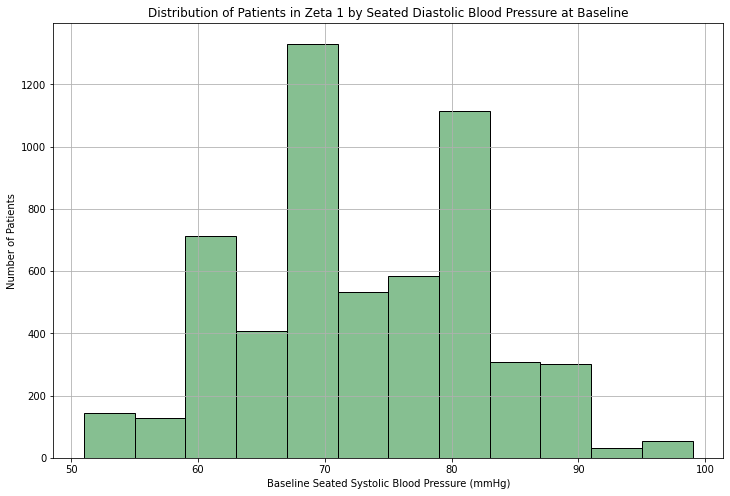

In [22]:
# Plot distribution of patients by Seated Diastolic Blood Pressure at Baseline
plt.figure(figsize=(12,8))
n, bins, patches = plt.hist(features[zeta == 1].Baseline_Seated_Diastolic_Blood_Pressure, 12, facecolor='#86bf91', edgecolor='black')
plt.xlabel('Baseline Seated Systolic Blood Pressure (mmHg)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patients in Zeta 1 by Seated Diastolic Blood Pressure at Baseline')
plt.grid(True)
plt.show()

In [23]:
(features[zeta == 1].Baseline_Seated_Diastolic_Blood_Pressure).describe()

count    5649.000000
mean       72.773588
std         9.402977
min        51.000000
25%        68.000000
50%        72.000000
75%        80.000000
max        99.000000
Name: Baseline_Seated_Diastolic_Blood_Pressure, dtype: float64

In [24]:
(features[zeta == 0].Baseline_Seated_Diastolic_Blood_Pressure).describe()

count    2635.000000
mean       78.223909
std         9.054251
min        51.000000
25%        70.000000
50%        80.000000
75%        84.000000
max        99.000000
Name: Baseline_Seated_Diastolic_Blood_Pressure, dtype: float64

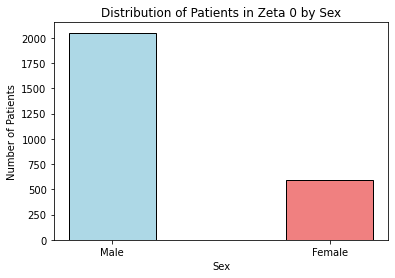

In [25]:
# Plot distribution of patients by Sex
plt.figure(figsize=(6,4))
plt.bar(['Male', 'Female'], (features.Sex)[zeta == 0].value_counts(), color = ['lightblue', 'lightcoral'],
        width = 0.4, edgecolor='black')
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.title("Distribution of Patients in Zeta 0 by Sex")
plt.show()

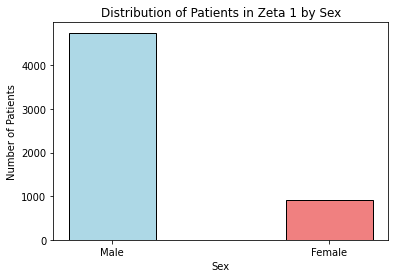

In [26]:
# Plot distribution of patients by Sex
plt.figure(figsize=(6,4))
plt.bar(['Male', 'Female'], (features.Sex)[zeta == 1].value_counts(), color = ['lightblue', 'lightcoral'],
        width = 0.4, edgecolor='black')
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.title("Distribution of Patients in Zeta 1 by Sex")
plt.show()

In [27]:
features[zeta == 0].Sex.value_counts()

Male      2051
Female     589
Name: Sex, dtype: int64

In [28]:
features[zeta == 1].Sex.value_counts()

Male      4745
Female     905
Name: Sex, dtype: int64

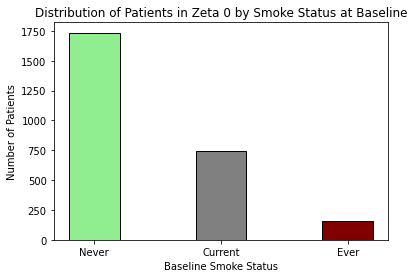

In [29]:
# Plot distribution of patients by Smoke Status
plt.bar(['Never', 'Current', 'Ever'], features[zeta == 0].Baseline_Smoke_status.value_counts(), color = ['lightgreen', 'grey', 'maroon'],
        width = 0.4, edgecolor='black')
plt.xlabel("Baseline Smoke Status")
plt.ylabel("Number of Patients")
plt.title("Distribution of Patients in Zeta 0 by Smoke Status at Baseline")
plt.show()

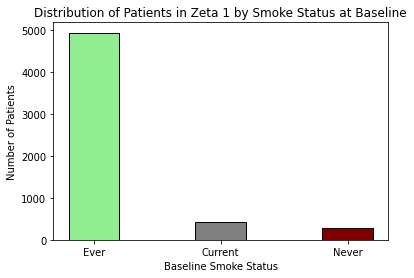

In [30]:
# Plot distribution of patients by Smoke Status
plt.bar(['Ever', 'Current', 'Never'], features[zeta == 1].Baseline_Smoke_status.value_counts(), color = ['lightgreen', 'grey', 'maroon'],
        width = 0.4, edgecolor='black')
plt.xlabel("Baseline Smoke Status")
plt.ylabel("Number of Patients")
plt.title("Distribution of Patients in Zeta 1 by Smoke Status at Baseline")
plt.show()

In [31]:
features[zeta == 1].Baseline_Smoke_status.value_counts()

Ever       4928
Current     432
Never       285
Name: Baseline_Smoke_status, dtype: int64

In [32]:
features[zeta == 0].Baseline_Smoke_status.value_counts()

Never      1734
Current     745
Ever        155
Name: Baseline_Smoke_status, dtype: int64

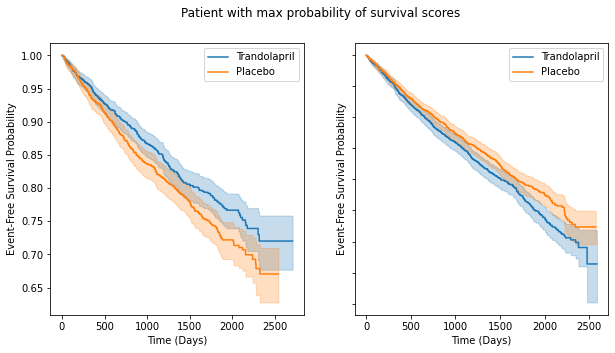

In [33]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

# Split the PEACE data into training and test data
x_train, x_test, y_train, y_test = train_test_split(features_prep, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Trandolapril'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 5803
Number of test data points: 2487


In [35]:
x_tr = x_train
t_tr = y_train['time']
e_tr = y_train['event']
a_tr = intervention[y_train.index]=='Trandolapril'

x_te = x_test
t_te = y_test['time']
e_te = y_test['event']
a_te = intervention[y_test.index]=='Trandolapril'

In [36]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(x_tr, t_tr, e_tr, a_tr, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:28<00:00,  3.54it/s]


In [37]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)

zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)

Train dataset 

    Confidence Interval for Zeta 0 is [0.92709967, 1.41968366]

    Confidence Interval for Zeta 1 is [0.78944218, 0.97286334]

Test dataset

    Confidence Interval for Zeta 0 is [0.82798362, 1.45041961]
    
    Confidence Interval for Zeta 1 is [0.69928853, 1.11034111]

In [38]:
hr_zeta0tr = treatment_effect('hazard_ratio', y_train[zeta_train == 0], (a_tr[zeta_train == 0]) == True, n_bootstrap=100)
CI_zeta0tr = np.quantile(hr_zeta0tr, [0.025, 0.975])
CI_zeta0tr

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...


array([0.92709967, 1.41968366])

In [39]:
hr_zeta1tr = treatment_effect('hazard_ratio', y_train[zeta_train == 1], a_tr[zeta_train == 1] == True, n_bootstrap=100)
CI_zeta1tr = np.quantile(hr_zeta1tr, [0.025, 0.975])
CI_zeta1tr

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...


array([0.78944218, 0.97286334])

In [40]:
hr_zeta1te = treatment_effect('hazard_ratio', y_test[zeta_test == 1], a_te[zeta_test == 1] == True, n_bootstrap=100)
CI_zeta1te = np.quantile(hr_zeta1te, [0.025, 0.975])
CI_zeta1te

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...


array([0.69928853, 1.11034111])

In [42]:
hr_zeta0te = treatment_effect('hazard_ratio', y_test[zeta_test == 0], a_te[zeta_test == 0] == True, n_bootstrap=100)
CI_zeta0te = np.quantile(hr_zeta0te, [0.025, 0.975])
CI_zeta0te

Bootstrapping...  100  number of times. This may take a while. Please be Patient...


array([0.82798362, 1.45041961])

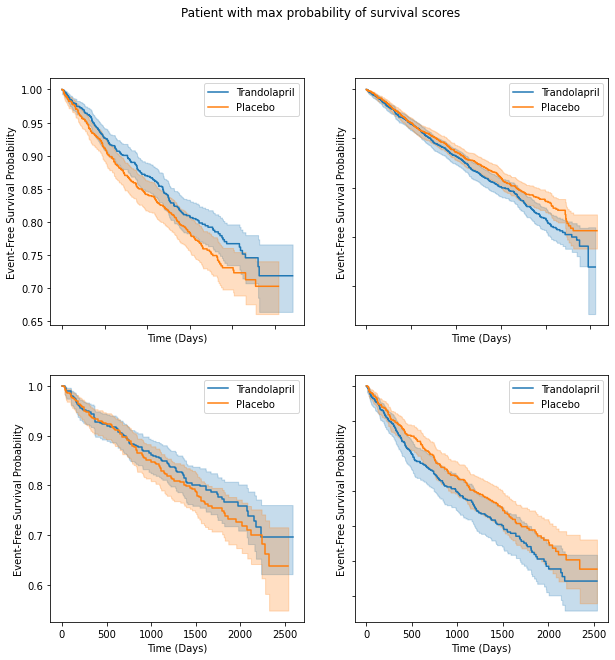

In [43]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (10, 10))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(y_train[zeta_train == 0], a_tr[zeta_train == 0], ax=ax1)
reporting.plot_kaplanmeier(y_train[zeta_train == 1], a_tr[zeta_train == 1], ax=ax2)
reporting.plot_kaplanmeier(y_test[zeta_test == 0], a_te[zeta_test == 0], ax=ax3) 
reporting.plot_kaplanmeier(y_test[zeta_test == 1], a_te[zeta_test == 1], ax=ax4)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()
# First row is training data
# Second row is test data
# First column is zeta 0
# Second column is zeta 1